# imports

In [1]:
from pathlib import Path
from typing import Optional, Any, Union

import numpy as np
import polars as pl

# plotting
import matplotlib.pyplot as plt
import plotly.express as px
from dash import Dash, dcc, html, Input, Output, State, callback_context
import plotly.graph_objects as go

# scipy
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# muutils
import muutils.tensor_info
from muutils.dbg import dbg, dbg_tensor

# attention-motifs
from attention_motifs.features.analysis import null_stats, filter_data, normalize_data
from attention_motifs.features.plotting import (
	plot_correlation_matrix,
	plot_embedding,
	apply_pca,
)

muutils.tensor_info.DEFAULT_SETTINGS["colored"] = True

from pathlib import Path
from typing import Optional, Any, Union

import numpy as np
from jaxtyping import Float

import polars as pl

# muutils
from muutils.jsonlines import jsonl_write, jsonl_load

# attention-motifs
from attention_motifs.bins import Bins
from attention_motifs.features.features import scalar_feature_table
from attention_motifs.features.hist_beta_fit import hist_beta_fit
from attention_motifs.util import prefix_dict
from attention_motifs.features.transition_tensor import tt_features
from attention_motifs.features.vec_features import vec_features
from attention_motifs.math.cos_sim import cosine_similarity_matrix
from attention_motifs.math.math import skew_lt
from attention_motifs.features.analysis import null_stats, filter_data, normalize_data

In [2]:
PATH_BASE: Path = Path("../data/features/")

# set up feature generation

In [3]:
def gram_features(A: Float[np.ndarray, "n_ctx n_ctx"]) -> dict[str, float]:
	# dbg_tensor(A)
	return prefix_dict(
		hist_beta_fit(
			A.flatten(),
			bins=Bins(n_bins=32, start=0.0, stop=1.0),
		),
		prefix="beta_hist",
	)
	# TODO: mass as a function of distance from diagonal

In [4]:
def compute_scalar_features(
	A: Float[np.ndarray, "n_ctx n_ctx"],
) -> dict[str, float]:
	# dbg_tensor(A)
	A_log: Float[np.ndarray, "n_ctx n_ctx"] = np.nan_to_num(np.log(A + 1e-9), nan=-10)
	# dbg_tensor(A_log)

	A_skew: Float[np.ndarray, "n_ctx n_ctx"] = skew_lt(A)
	# dbg_tensor(A_skew)
	A_log_skew: Float[np.ndarray, "n_ctx n_ctx"] = skew_lt(A_log)

	return dict(
		# diagonal: standard features, fit diff to beta dist
		**prefix_dict(vec_features(A.diagonal()), prefix="diag"),
		# off-diagonal: standard features, fit diff to beta dist
		**prefix_dict(vec_features(A[:, 0]), prefix="first_tok"),
		# transition tensor: standard features, standard features on diff, linear envelope on transition time
		# 	TODO: standard features on decay rate
		**prefix_dict(
			tt_features(A),
			prefix="markov_transition",
		),
		# # {log, raw} gram matrix of {rows, cols, rows of skewed}: beta fit hist
		# # 	TODO: fit fft in `gram_features`, but this is expensive
		**prefix_dict(
			gram_features(A @ A.T),
			prefix=["gram", "row"],
		),
		**prefix_dict(
			gram_features(A.T @ A),
			prefix=["gram", "col"],
		),
		**prefix_dict(
			gram_features(A_skew.T @ A_skew),
			prefix=["gram", "skew"],
		),
		**prefix_dict(
			gram_features(cosine_similarity_matrix(A_log)),
			prefix=["log", "gram", "row"],
		),
		**prefix_dict(
			gram_features(cosine_similarity_matrix(A_log, col=True)),
			prefix=["log", "gram", "col"],
		),
		**prefix_dict(
			gram_features(cosine_similarity_matrix(A_log_skew)),
			prefix=["log", "gram", "skew"],
		),
	)

# run feature gen

In [ ]:
DATA_RAW: pl.DataFrame = scalar_feature_table(
	features_func=compute_scalar_features,
	models=["pythia-14m", "tiny-stories-1M"],
)

# save raw data

In [ ]:
DATA_RAW.write_ndjson(PATH_BASE / "raw.jsonl")

In [ ]:
# uncomment and run to load raw data from file instead of regenerating
# DATA_RAW = pl.read_ndjson(PATH_BASE / "raw.jsonl")

# basic data inspection

In [6]:
DATA_RAW

feat.first_tok.zero_crossing_rate,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.log.gram.col.beta_hist.hist.raw.L2_norm,feat.log.gram.col.beta_hist.hist.raw.L1_norm,feat.diag.energy,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.diag.kurtosis,feat.gram.row.beta_hist.hist.raw.std,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.markov_transition.time.entropy,feat.gram.col.beta_hist.hist.raw.rms,feat.first_tok.linreg.slope,feat.log.gram.col.beta_hist.hist.raw.zero_crossing_rate,feat.diag.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.first_tok.L2_norm,feat.markov_transition.time.linreg.intercept,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.log.gram.col.beta_hist.hist.raw.rms,feat.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.time.psd_total_power,feat.gram.row.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.gram.skew.beta_hist.hist.raw.variance,feat.gram.col.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.rms,feat.diag.std,feat.first_tok.skewness,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.markov_transition.time.std,feat.markov_transition.time.L2_norm,feat.markov_transition.time.zero_crossing_rate,feat.markov_transition.diff.linreg.intercept,feat.first_tok.linreg.intercept,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,…,feat.gram.skew.beta_hist.hist.raw.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.col.beta_hist.hist.raw.median,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.markov_transition.env.upper.slope,feat.gram.col.beta_hist.hist.raw.variance,feat.markov_transition.time.mean,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.row.beta_hist.hist.raw.entropy,feat.log.gram.row.beta_hist.hist.raw.kurtosis,feat.gram.row.beta_hist.hist.raw.rms,feat.markov_transition.diff.skewness,feat.diag.linreg.slope,feat.gram.skew.beta_hist.hist.raw.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.skew.beta_hist.hist.raw.entropy,activation.layer,feat.diag.skewness,feat.gram.col.beta_hist.hist.raw.median,feat.markov_transition.diff.zero_crossing_rate,feat.markov_transition.diff.linreg.slope,feat.gram.skew.beta_hist.hist.raw.energy,feat.first_tok.std,feat.log.gram.row.beta_hist.hist.raw.mean,feat.markov_transition.diff.std,feat.markov_transition.diff.rms,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.skewness,activation.prompt,feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.diag.L2_norm,feat.gram.skew.beta_hist.hist.raw.mean,feat.diag.rms,feat.log.gram.skew.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.energy,feat.gram.row.beta_hist.hist.raw.variance
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64
0.0,25.775427,5.451335,0.12987,0.164973,6.369844,0.029031,5.722651,23.723699,131.525631,1.792928,0.0,94.085666,-0.002826,0.0,1.596638,0.029276,0.017348,0.0,4.743038,0.734656,0.979052,0.0,1.094303,0.742355,11563.263566,39.319073,0.756456,0.165037,3.412402,0.931865,0.0,0.0,0.0,0.034932,0.235895,0.94515,…,19.709615,0.0,0.0,55.760361,0.0,7541.80449,0.0,-5.56048,2.32782,23.333774,30.837409,10.488514,-0.001612,0.235303,3.151275,0.200622,0,1.939376,1.896931,0.0,-0.000466,397792.161079,0.169565,0.163203,0.094072,0.094072,39.319073,4.845672,"""MjWkadUxH4Z5nfLEFtUc1w""",0.0,4.927002,0.022139,35.058429,0.236381,16.549212,17.271027,562.813909
0.0,26.048842,13.658481,0.144865,0.159597,16.274387,0.043626,-0.29873,72.642336,123.309449,2.131102,0.0,134.413585,-0.001706,0.0,7.588164,0.028574,0.014805,0.0,5.298928,0.81948,0.782567,0.0,4.41590

In [7]:
set(DATA_RAW.dtypes)

{Float64, Int64, String}

In [8]:
DATA_RAW.head()

feat.first_tok.zero_crossing_rate,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.log.gram.col.beta_hist.hist.raw.L2_norm,feat.log.gram.col.beta_hist.hist.raw.L1_norm,feat.diag.energy,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.diag.kurtosis,feat.gram.row.beta_hist.hist.raw.std,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.markov_transition.time.entropy,feat.gram.col.beta_hist.hist.raw.rms,feat.first_tok.linreg.slope,feat.log.gram.col.beta_hist.hist.raw.zero_crossing_rate,feat.diag.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.first_tok.L2_norm,feat.markov_transition.time.linreg.intercept,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.log.gram.col.beta_hist.hist.raw.rms,feat.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.time.psd_total_power,feat.gram.row.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.gram.skew.beta_hist.hist.raw.variance,feat.gram.col.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.rms,feat.diag.std,feat.first_tok.skewness,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.markov_transition.time.std,feat.markov_transition.time.L2_norm,feat.markov_transition.time.zero_crossing_rate,feat.markov_transition.diff.linreg.intercept,feat.first_tok.linreg.intercept,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,…,feat.gram.skew.beta_hist.hist.raw.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.col.beta_hist.hist.raw.median,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.markov_transition.env.upper.slope,feat.gram.col.beta_hist.hist.raw.variance,feat.markov_transition.time.mean,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.row.beta_hist.hist.raw.entropy,feat.log.gram.row.beta_hist.hist.raw.kurtosis,feat.gram.row.beta_hist.hist.raw.rms,feat.markov_transition.diff.skewness,feat.diag.linreg.slope,feat.gram.skew.beta_hist.hist.raw.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.skew.beta_hist.hist.raw.entropy,activation.layer,feat.diag.skewness,feat.gram.col.beta_hist.hist.raw.median,feat.markov_transition.diff.zero_crossing_rate,feat.markov_transition.diff.linreg.slope,feat.gram.skew.beta_hist.hist.raw.energy,feat.first_tok.std,feat.log.gram.row.beta_hist.hist.raw.mean,feat.markov_transition.diff.std,feat.markov_transition.diff.rms,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.skewness,activation.prompt,feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.diag.L2_norm,feat.gram.skew.beta_hist.hist.raw.mean,feat.diag.rms,feat.log.gram.skew.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.energy,feat.gram.row.beta_hist.hist.raw.variance
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64
0.0,25.775427,5.451335,0.12987,0.164973,6.369844,0.029031,5.722651,23.723699,131.525631,1.792928,0.0,94.085666,-0.002826,0.0,1.596638,0.029276,0.017348,0.0,4.743038,0.734656,0.979052,0.0,1.094303,0.742355,11563.263566,39.319073,0.756456,0.165037,3.412402,0.931865,0.0,0.0,0.0,0.034932,0.235895,0.94515,…,19.709615,0.0,0.0,55.760361,0.0,7541.80449,0.0,-5.56048,2.32782,23.333774,30.837409,10.488514,-0.001612,0.235303,3.151275,0.200622,0,1.939376,1.896931,0.0,-0.000466,397792.161079,0.169565,0.163203,0.094072,0.094072,39.319073,4.845672,"""MjWkadUxH4Z5nfLEFtUc1w""",0.0,4.927002,0.022139,35.058429,0.236381,16.549212,17.271027,562.813909
0.0,26.048842,13.658481,0.144865,0.159597,16.274387,0.043626,-0.29873,72.642336,123.309449,2.131102,0.0,134.413585,-0.001706,0.0,7.588164,0.028574,0.014805,0.0,5.298928,0.81948,0.782567,0.0,4.41590

In [9]:
DATA_RAW.describe()

statistic,feat.first_tok.zero_crossing_rate,feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.log.gram.col.beta_hist.hist.raw.L2_norm,feat.log.gram.col.beta_hist.hist.raw.L1_norm,feat.diag.energy,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.diag.kurtosis,feat.gram.row.beta_hist.hist.raw.std,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.markov_transition.time.entropy,feat.gram.col.beta_hist.hist.raw.rms,feat.first_tok.linreg.slope,feat.log.gram.col.beta_hist.hist.raw.zero_crossing_rate,feat.diag.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.first_tok.L2_norm,feat.markov_transition.time.linreg.intercept,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.log.gram.col.beta_hist.hist.raw.rms,feat.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.time.psd_total_power,feat.gram.row.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.gram.skew.beta_hist.hist.raw.variance,feat.gram.col.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.rms,feat.diag.std,feat.first_tok.skewness,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.markov_transition.time.std,feat.markov_transition.time.L2_norm,feat.markov_transition.time.zero_crossing_rate,feat.markov_transition.diff.linreg.intercept,feat.first_tok.linreg.intercept,…,feat.gram.skew.beta_hist.hist.raw.L2_norm,feat.log.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.col.beta_hist.hist.raw.median,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.markov_transition.env.upper.slope,feat.gram.col.beta_hist.hist.raw.variance,feat.markov_transition.time.mean,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.row.beta_hist.hist.raw.entropy,feat.log.gram.row.beta_hist.hist.raw.kurtosis,feat.gram.row.beta_hist.hist.raw.rms,feat.markov_transition.diff.skewness,feat.diag.linreg.slope,feat.gram.skew.beta_hist.hist.raw.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.skew.beta_hist.hist.raw.entropy,activation.layer,feat.diag.skewness,feat.gram.col.beta_hist.hist.raw.median,feat.markov_transition.diff.zero_crossing_rate,feat.markov_transition.diff.linreg.slope,feat.gram.skew.beta_hist.hist.raw.energy,feat.first_tok.std,feat.log.gram.row.beta_hist.hist.raw.mean,feat.markov_transition.diff.std,feat.markov_transition.diff.rms,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.skewness,activation.prompt,feat.gram.skew.beta_hist.hist.raw.zero_crossing_rate,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.diag.L2_norm,feat.gram.skew.beta_hist.hist.raw.mean,feat.diag.rms,feat.log.gram.skew.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.energy,feat.gram.row.beta_hist.hist.raw.variance
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,…,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,"""19456""",19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0,19456.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [10]:
# print unique values for columns which start with "activations"
print(f"{DATA_RAW['activation.model'].unique() = }")

DATA_RAW['activation.model'].unique() = shape: (2,)
Series: 'activation.model' [str]
[
	"pythia-14m"
	"tiny-stories-1M"
]


In [11]:
for col in DATA_RAW.columns:
	if col.startswith("activation"):
		print(f"{col = }")

col = 'activation.n_ctx'
col = 'activation.model'
col = 'activation.head'
col = 'activation.cls'
col = 'activation.cache_key'
col = 'activation.layer'
col = 'activation.prompt'


In [12]:
null_stats(DATA_RAW)

feature,missing_count,missing_frac
str,i64,f64
"""feat.markov_transition.time.sk…",18627,0.957391
"""feat.markov_transition.time.ku…",18627,0.957391
"""feat.first_tok.zero_crossing_r…",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""feat.gram.row.beta_hist.hist.r…",0,0.0
…,…,…
"""feat.gram.skew.beta_hist.hist.…",0,0.0
"""feat.diag.rms""",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0


# filter nans and certain models

In [13]:
# this will filter all-nan rows
DATA_FILTERED: pl.DataFrame = filter_data(
	DATA_RAW,
	# tinystories and small pythia models look very different in embedding space, so we get rid of them
	# remove_models=["tiny-stories-1M", "pythia-14m"],
)
null_stats(DATA_FILTERED)

Not removing any models
Removing 16/176 feat.* columns due to zero variance or excessive missing values
feat.first_tok.zero_crossing_rate                            μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=19456 dtype=float64
feat.log.gram.col.beta_hist.hist.raw.zero_crossing_rate      μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=19456 dtype=float64
feat.markov_transition.time.zero_crossing_rate               μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=19456 dtype=float64
feat.log.gram.row.beta_hist.hist.raw.median                  μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=19456 dtype=float64
feat.log.gram.row.beta_hist.hist.raw.zero_crossing_rate      μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=19456 dtype=float64
feat.gram.row.beta_hist.hist.raw.zero_crossing_rate          μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=19456 dtype=float64
feat.markov_transition.env.lower.intercept                   μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] shape=19456 dtype=float64
feat.markov_transition.time.skewnes

feature,missing_count,missing_frac
str,i64,f64
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""feat.gram.row.beta_hist.hist.r…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.diag.energy""",0,0.0
…,…,…
"""feat.gram.skew.beta_hist.hist.…",0,0.0
"""feat.diag.rms""",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0


# scaling

In [14]:
# Pick feature columns
FEATURE_COLS: list[str] = [
	col for col in DATA_FILTERED.columns if col.startswith("feat.")
]

In [15]:
DATA_SCALED: pl.DataFrame = normalize_data(DATA_FILTERED, FEATURE_COLS)
DATA_SCALED

feat.log.gram.skew.beta_hist.hist.raw.kurtosis,feat.gram.row.beta_hist.hist.raw.L2_norm,feat.log.gram.col.beta_hist.hist.raw.L2_norm,feat.log.gram.col.beta_hist.hist.raw.L1_norm,feat.diag.energy,feat.log.gram.skew.beta_hist.hist.raw.linreg.r2,feat.diag.kurtosis,feat.gram.row.beta_hist.hist.raw.std,feat.gram.col.beta_hist.hist.raw.linreg.intercept,feat.log.gram.skew.beta_hist.hist.raw.linreg.intercept,feat.markov_transition.time.entropy,feat.gram.col.beta_hist.hist.raw.rms,feat.first_tok.linreg.slope,feat.diag.psd_total_power,feat.log.gram.row.beta_hist.hist.raw.linreg.slope,feat.first_tok.L2_norm,feat.markov_transition.time.linreg.intercept,feat.log.gram.col.beta_hist.hist.raw.skewness,feat.log.gram.col.beta_hist.hist.raw.rms,feat.gram.row.beta_hist.hist.raw.autocorr_lag1,feat.markov_transition.time.psd_total_power,feat.gram.row.beta_hist.hist.raw.skewness,feat.gram.skew.beta_hist.hist.raw.autocorr_lag1,feat.gram.skew.beta_hist.hist.raw.variance,feat.gram.col.beta_hist.hist.raw.mean,feat.log.gram.row.beta_hist.hist.raw.rms,feat.diag.std,feat.first_tok.skewness,feat.log.gram.skew.beta_hist.hist.raw.L1_norm,feat.markov_transition.time.std,feat.markov_transition.time.L2_norm,feat.markov_transition.diff.linreg.intercept,feat.first_tok.linreg.intercept,feat.gram.col.beta_hist.hist.raw.autocorr_lag1,feat.gram.col.beta_hist.hist.raw.L2_norm,feat.markov_transition.time.energy,feat.gram.skew.beta_hist.hist.raw.std,…,feat.gram.row.beta_hist.hist.raw.median,feat.gram.skew.beta_hist.hist.raw.median,feat.gram.row.beta_hist.hist.raw.kurtosis,feat.gram.skew.beta_hist.hist.raw.L2_norm,feat.gram.row.beta_hist.hist.raw.linreg.intercept,feat.markov_transition.env.upper.slope,feat.gram.col.beta_hist.hist.raw.variance,feat.markov_transition.time.mean,feat.gram.skew.beta_hist.hist.raw.linreg.slope,feat.gram.row.beta_hist.hist.raw.entropy,feat.log.gram.row.beta_hist.hist.raw.kurtosis,feat.gram.row.beta_hist.hist.raw.rms,feat.markov_transition.diff.skewness,feat.diag.linreg.slope,feat.gram.skew.beta_hist.hist.raw.linreg.r2,feat.log.gram.skew.beta_hist.hist.raw.rms,feat.log.gram.skew.beta_hist.hist.raw.entropy,activation.layer,feat.diag.skewness,feat.gram.col.beta_hist.hist.raw.median,feat.markov_transition.diff.zero_crossing_rate,feat.markov_transition.diff.linreg.slope,feat.gram.skew.beta_hist.hist.raw.energy,feat.first_tok.std,feat.log.gram.row.beta_hist.hist.raw.mean,feat.markov_transition.diff.std,feat.markov_transition.diff.rms,feat.gram.col.beta_hist.hist.raw.L1_norm,feat.gram.skew.beta_hist.hist.raw.skewness,activation.prompt,feat.log.gram.row.beta_hist.hist.raw.skewness,feat.diag.L2_norm,feat.gram.skew.beta_hist.hist.raw.mean,feat.diag.rms,feat.log.gram.skew.beta_hist.hist.raw.psd_total_power,feat.log.gram.col.beta_hist.hist.raw.energy,feat.gram.row.beta_hist.hist.raw.variance
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64
0.241786,-0.431346,0.168357,-0.499745,0.220855,-0.391807,-0.975054,-0.505888,0.94315,-0.344892,-0.150619,-0.072471,0.091667,0.006785,-0.397889,-0.104345,0.118355,0.681093,0.168357,0.961021,-0.045923,-0.876124,-0.488586,-0.087619,0.89625,0.112254,0.278822,-0.669495,-0.27325,-0.154915,-0.153414,-0.250264,0.105316,0.485186,-0.072471,-0.053947,0.116402,…,1.401539,-0.256413,-0.781248,0.095596,0.073964,-0.181426,-0.249075,-0.096702,-0.374769,0.961193,0.709277,-0.431346,0.214397,0.060889,-0.549583,-0.311198,-0.403167,0,-1.197101,-0.396794,-0.111103,0.315314,-0.084326,0.234346,-0.398426,-0.197343,-0.196796,0.89625,0.701655,"""MjWkadUxH4Z5nfLEFtUc1w""",0.673998,0.254704,0.2024,0.498966,-0.343456,0.117291,-0.516278
0.427317,0.686275,1.467189,-1.390047,1.58831,0.466565,-1.239506,0.656404,0.355821,-0.064161,-0.150619,1.107994,0.434141,1.85054,-1.531702,-0.279698,0.118355,1.595861,1.467189,

In [16]:
null_stats(DATA_SCALED)

feature,missing_count,missing_frac
str,i64,f64
"""feat.log.gram.skew.beta_hist.h…",0,0.0
"""feat.gram.row.beta_hist.hist.r…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.log.gram.col.beta_hist.hi…",0,0.0
"""feat.diag.energy""",0,0.0
…,…,…
"""feat.gram.skew.beta_hist.hist.…",0,0.0
"""feat.diag.rms""",0,0.0
"""feat.log.gram.skew.beta_hist.h…",0,0.0


# PCA

In [17]:
dbg_tensor(DATA_SCALED[FEATURE_COLS].to_numpy())

[ <ipykernel>:1 ] DATA_SCALED[FEATURE_COLS].to_numpy(): μ=-0.00 σ=1.00 x̃=-0.12 R=[-28.48,109.20] ℙ=|▂█▃▂   | shape=(19456,160) dtype=float64


array([[ 0.2417858 , -0.43134615,  0.16835738, ..., -0.34345615,
         0.11729096, -0.51627815],
       [ 0.42731746,  0.68627521,  1.46718941, ..., -0.41039501,
         1.43105763,  0.236074  ],
       [ 0.22804608, -1.14874678,  0.49679152, ..., -0.27465567,
         0.43595471, -0.60597169],
       ...,
       [ 0.67796578, -1.01699671, -0.31587219, ...,  0.25796305,
        -0.33580709, -0.60272969],
       [ 0.65367005, -0.79460474, -0.64761606, ...,  0.29032647,
        -0.63471698, -0.57572724],
       [ 0.65963021, -0.99274525, -0.68050268, ...,  0.27047706,
        -0.66383898, -0.6003027 ]])

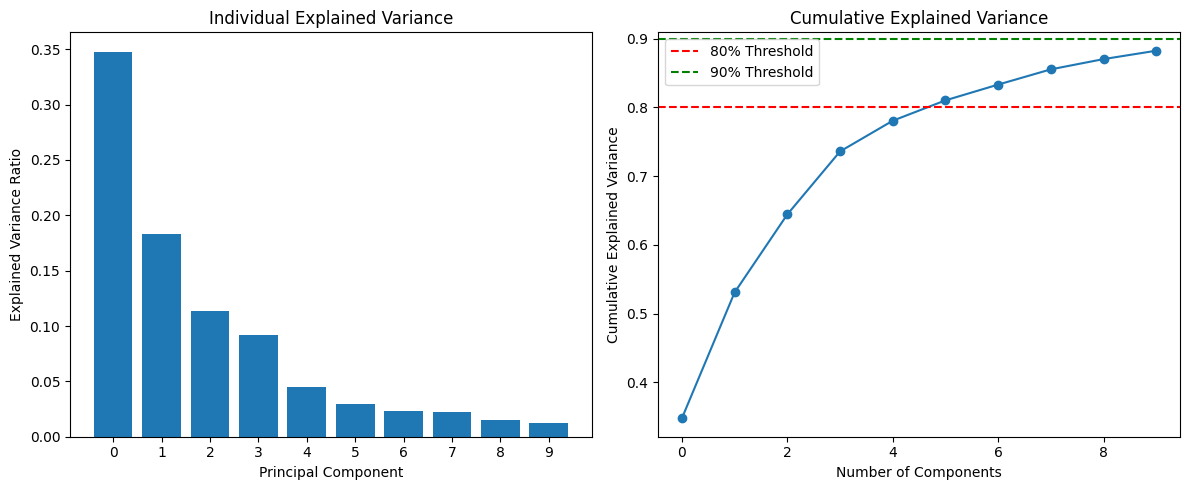

Number of components: 10
Total explained variance: 0.8826
Components needed for 80% variance: 6
Components needed for 90% variance: 1


In [18]:
# PCA
pca_data: np.ndarray
pca_obj: PCA
pca_data, pca_obj = apply_pca(DATA_SCALED, n_components=10, feature_cols=FEATURE_COLS)

In [19]:
# save some data
DATA_SCALED.write_ndjson(PATH_BASE / "scaled.jsonl")
dbg_tensor(pca_data)
np.save(PATH_BASE / "pca.npy", pca_data)

# only columns that start with "activation."
# for labelling the PCA plot in the webapp
data_meta: pl.DataFrame = DATA_SCALED[[
	col for col in DATA_SCALED.columns if col.startswith("activation.")
]]
data_meta = data_meta.write_ndjson(PATH_BASE / "meta.jsonl")

[ <ipykernel>:3 ] pca_data: μ=0.00 σ=3.76 x̃=-0.08 R=[-33.11,152.21] ℙ=|▅█▃▁▁▁ | shape=(19456,10) dtype=float64


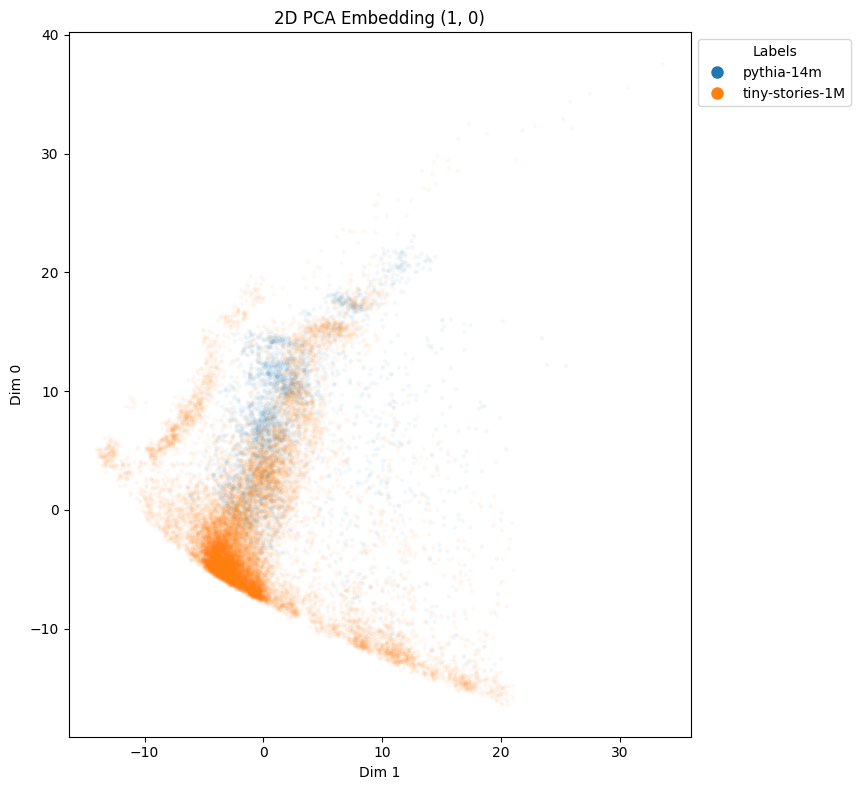

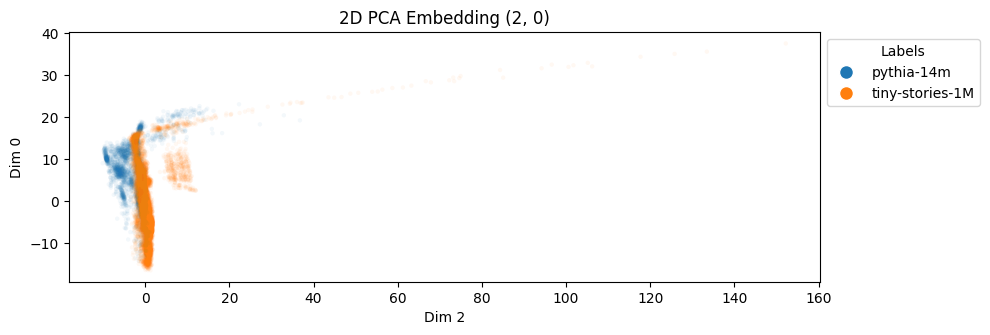

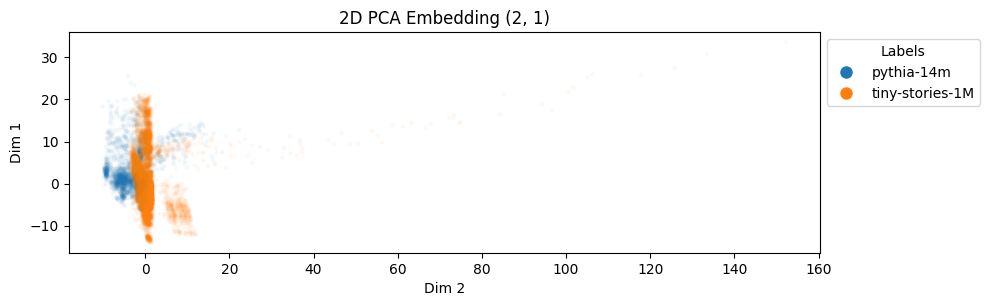

In [20]:
for i in range(1, 3):
	for j in range(0, i):
		plot_embedding(
			pca_data,
			DATA_SCALED["activation.model"],
			(i, j),
			alpha=0.05,
			marker_size=10,
			title=f"2D PCA Embedding ({i}, {j})",
		)